This is the overall workflow for all the steps, including,
1) Generate mesh, including random field
2) Run ogs
3) Run pvd

This scripts allows running everything sequentially with one click. But for debugging, please use the respective scripts of these 3 steps, and use 'paraview' the look at the domain_with_stiffness.vtu and uplift.pvd.

Generate mesh and random field.

c:\Users\glori\Documents\tasks\ogs_exercise\2D\_out


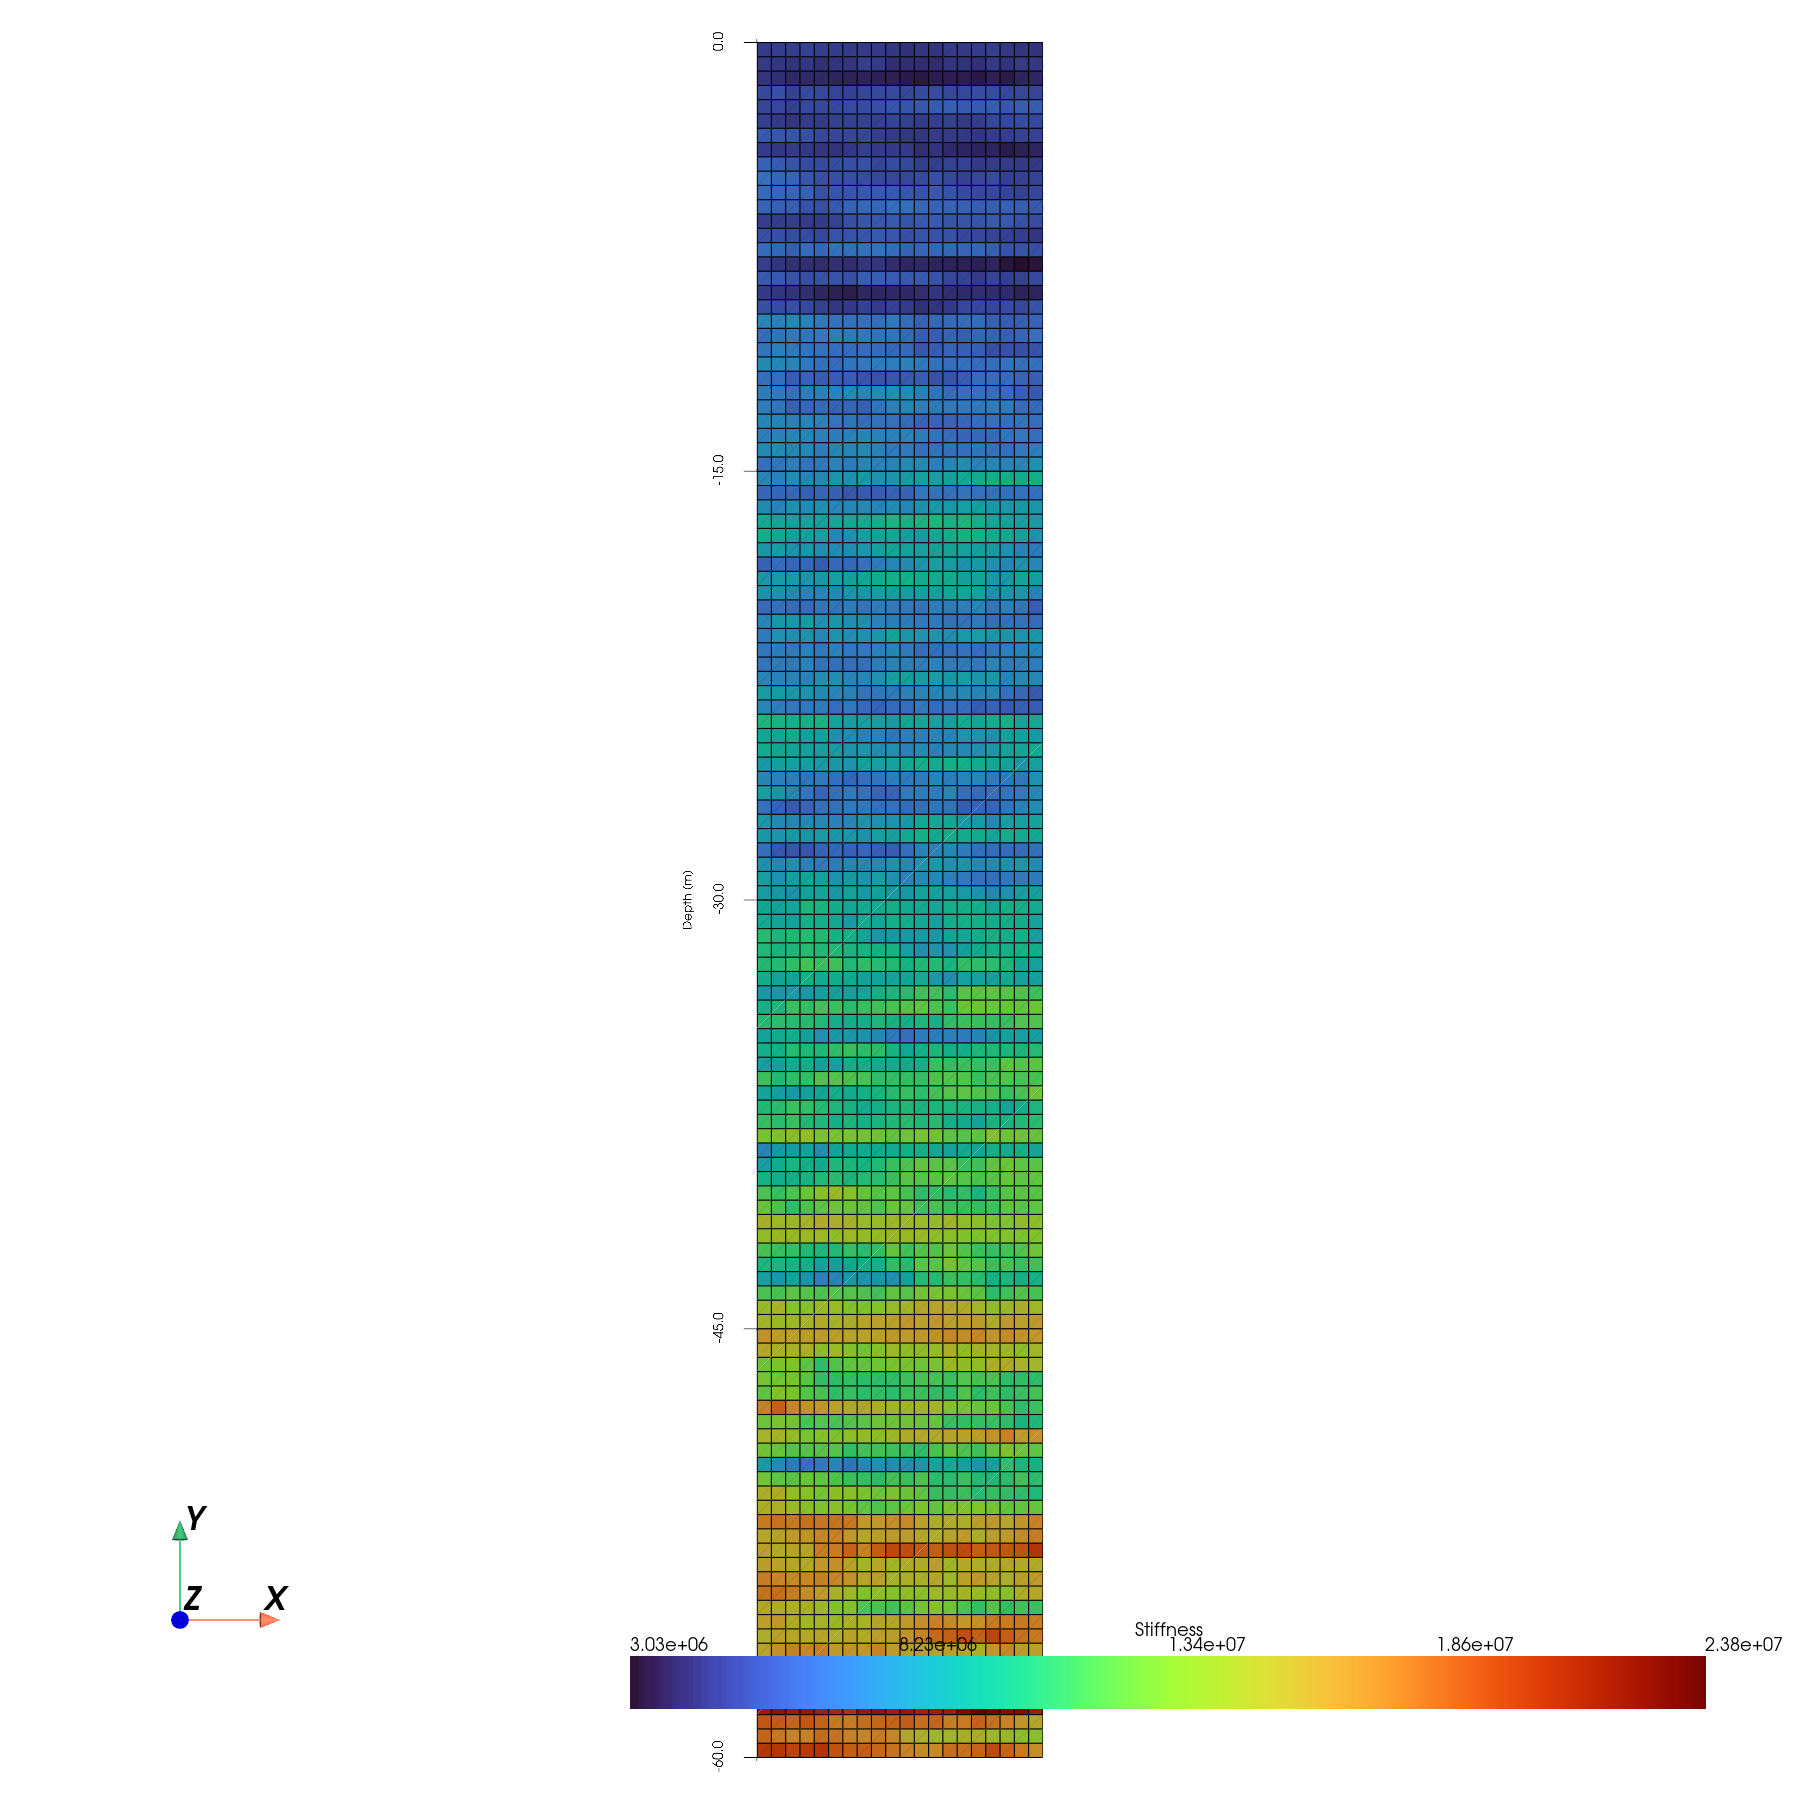

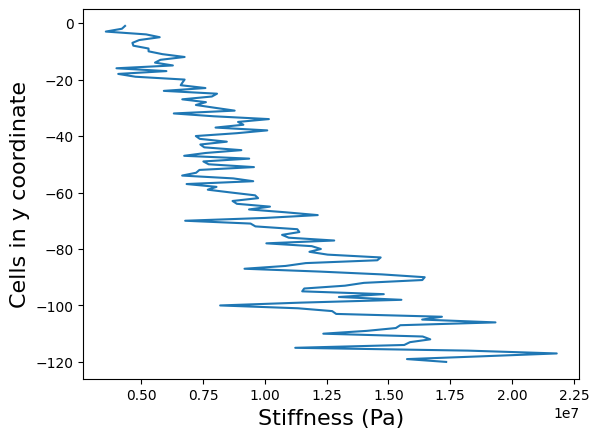

stiffness at -30m 7984854.251468899
stiffness at -50m 7725768.217269714


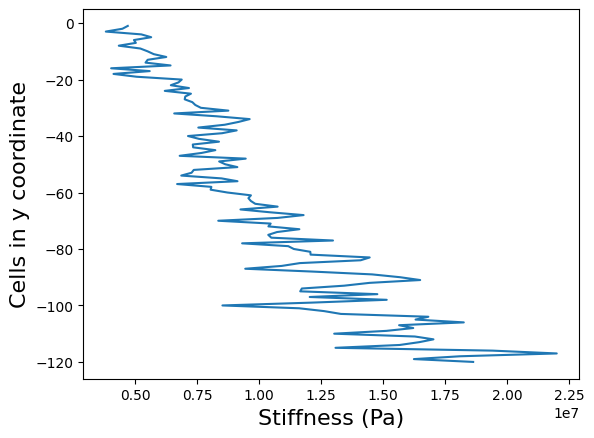

c:\Users\glori\Documents\tasks\ogs_exercise\2D


In [1]:
%run ./generate_mesh_2D_cell_RF.ipynb

Run Opengeosys.

In [2]:
%run ./run_ogs.ipynb

c:\Users\glori\Documents\tasks\ogs_exercise\2D\_out
OGS finished with project file input.prj.
Execution took 24.51071524620056 s
Project file written to output.
c:\Users\glori\Documents\tasks\ogs_exercise\2D


Run pvd. A useful website: https://github.com/joergbuchwald/VTUinterface/blob/master/README_python.md

In [3]:
import vtuIO
import matplotlib.pyplot as plt

In [4]:
pvdfile = vtuIO.PVDIO("./_out/uplift.pvd", interpolation_backend="scipy", dim=2)
time = pvdfile.timesteps

points = {"pt0": (0, 0, 0), "pt1": (0, -30, 0), "pt2": (0, -50, 0)}

Text(-10, 0.6063413184391352, '0.606')

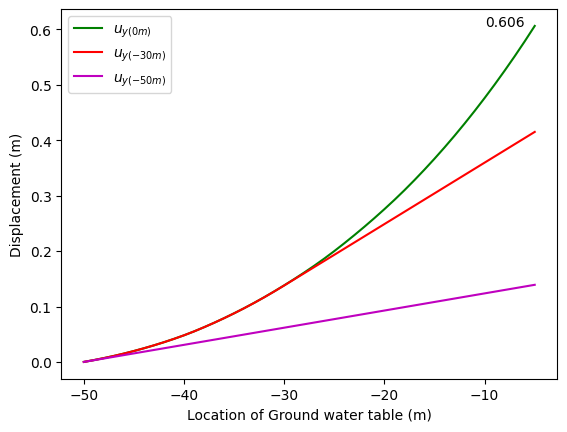

In [5]:
displacement_linear = pvdfile.read_time_series("displacement", points, interpolation_method="linear")

GWT = -50 + time * 1

plt.plot(GWT, displacement_linear["pt0"][:, 1], "g-",  label="$u_{y(" + str(points["pt0"][1]) + "m)}$")
plt.plot(GWT, displacement_linear["pt1"][:, 1], "r-", label="$u_{y(" + str(points["pt1"][1]) + "m)}$")
plt.plot(GWT, displacement_linear["pt2"][:, 1], "m-", label="$u_{y(" + str(points["pt2"][1]) + "m)}$")

plt.legend()
plt.xlabel("Location of Ground water table (m)")
plt.ylabel("Displacement (m)")
last_data= displacement_linear["pt0"][-1, 1]
last_data_3decimal= "%.3f" % round(last_data, 3)
plt.annotate(str(last_data_3decimal),(-10, last_data))